# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [2]:
# Specify the names of the solver(s) and problem(s) to test.
#solver_abbr_names = [ "SQPASTRODF"]
#COBYQA testing
solver_abbr_names = ["SQPASTRODF", "COBYQA"]
problem_abbr_names = ["SAN-4"]
solver_factors = [{"feas_tol": 1e-2, 
                   "easy_solve": False, 
                   "use_gradients":False, 
                   "sampling_method": "adaptive",
                   "mu": .1, 
                   "reuse_interpolation_set": True,
                   "recenter_mode": "shift",
                  },
                  {"sample_size": 5, 
                   "feas_tol": 1e-2}]

# # General IBO testing
# solver_abbr_names = ["SQPASTRODF", "SQPASTRODF"]
# problem_abbr_names = ["SAN-3"]
# solver_factors = [{"feas_tol": 1e-4, 
#                    "delta_0":1, "a_normal": .9, 
#                    "a_tangent":.1, 
#                    "mu":.1, 
#                    "easy_solve": False, 
#                    "use_gradients":False, 
#                    "sigma_min": 1, 
#                    "sigma_b_max":100,
#                    "sampling_method": "adaptive",
#                    "gamma_1": 1.41421356237,
#                    "eta_1" : .1,
#                    "eta_2": .7
#                   },
#                   {"feas_tol": 1e-4, 
#                    "delta_0":1, 
#                    "a_normal": .9, 
#                    "a_tangent":.1, 
#                    "mu":.1, 
#                    "easy_solve": False, 
#                    "use_gradients":False, 
#                    "sigma_min": 1, 
#                    "sigma_b_max":100,
#                    "sampling_method": "IBO",
#                    "lambda_min":5, 
#                    "gamma_1": 1.41421356237,
#                    "eta_1" : .1,
#                    "eta_2": .7}]
# solver_renames = ["SQPASTRODF", "IBO"]
# solver_abbr_names = ["SQPASTRODF","SQPASTRODF"]
# problem_abbr_names = ["SAN-4"]
# solver_factors = [
#                   {"feas_tol": 1e-2, 
#                    "easy_solve": False, 
#                    "use_gradients":False, 
#                    "sampling_method": "adaptive",
#                    "mu": 1,
#                    },
#                 {"feas_tol": 1e-2, 
#                    "easy_solve": False, 
#                    "use_gradients":False, 
#                    "sampling_method": "IBO",
#                    "mu": 1,
                    
#                 }
    
#                     ]
# solver_renames = ["SQP-ASTRO-DF"]
# solver_abbr_names = ["SQPASTRODF"]
# problem_abbr_names = ["SAN-4"]
# solver_factors = [{"feas_tol": 1e-2, 
#                    "easy_solve": False, 
#                    "use_gradients":False, 
#                    "sampling_method": "adaptive",
#                    "mu": 1,
#                   }]
#solver_factors = [{}]
problem_factors = [{"budget":10000, "total_cost": 5}]
# small SAN problem factors
# arcs = [
#     (1, 2),
#     (1, 3),
#     (2, 4),
#     (3, 4),
#     (4, 5),
# ]
# model_factors = {"arcs": arcs, "num_nodes":5}
# arc_means = (1.0,)*5
# initial_sol = (8.0,)*5
# arc_cost = (1.0,)*5
# problem_factors = [{"budget":30000, 
#                     "total_cost": 2,
#                     "arcs": arcs, 
#                     "num_nodes":5,
#                     "initial_solution": initial_sol,
#                     "arc_means": arc_means,
#                     "arc_costs": arc_cost
#                    }]
num_macroreps = 10
num_postreps = 50
num_postreps_init_opt = 50

In [3]:
# Initialize an instance of the experiment class.
from simopt.experiment_base import ProblemsSolvers

mymetaexperiment = ProblemsSolvers(
    solver_names=solver_abbr_names, 
    problem_names=problem_abbr_names, 
    solver_factors = solver_factors, 
    problem_factors = problem_factors,
    #solver_renames = solver_renames
)

# Write to log file.
mymetaexperiment.log_group_experiment_results()

In [5]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)

In [6]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
mymetaexperiment.post_replicate(n_postreps=num_postreps)

Post-processing results.


In [7]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

Post-normalizing results.


In [8]:
#mymetaexperiment.report_group_statistics()

Plotting results...
Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_all_prog_curves_unnorm.png')]
Plotting complete!


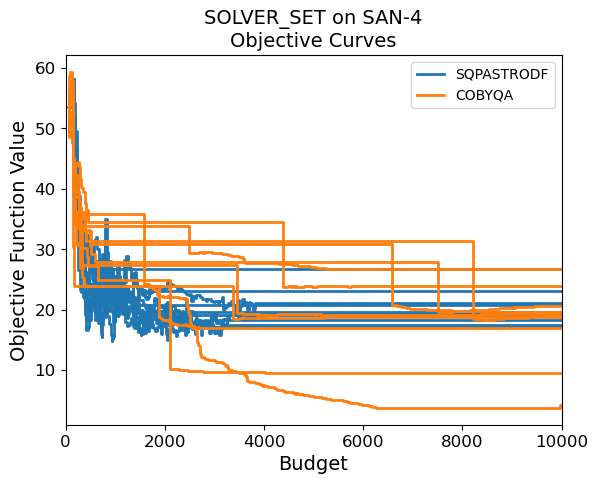

In [9]:
# Produce basic plots.

from simopt.experiment_base import (
    plot_area_scatterplots,  # noqa: F401
    plot_feasibility_progress,  # noqa: F401
    plot_progress_curves,  # noqa: F401
    plot_solvability_cdfs,  # noqa: F401
    plot_solvability_profiles,  # noqa: F401
    plot_terminal_feasibility,  # noqa: F401
    plot_terminal_progress,  # noqa: F401
    plot_terminal_scatterplots, 
    plot_det_feasibility,
    plot_det_terminal_feasibility,
    PlotType # noqa: F401
)

print("Plotting results...")


def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_progress_curves(
        experiments=mymetaexperiment.experiments[0] + mymetaexperiment.experiments[1], plot_type=PlotType.ALL, normalize=False
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_all_prog_curves_unnorm (1).png')]
Plotting complete!


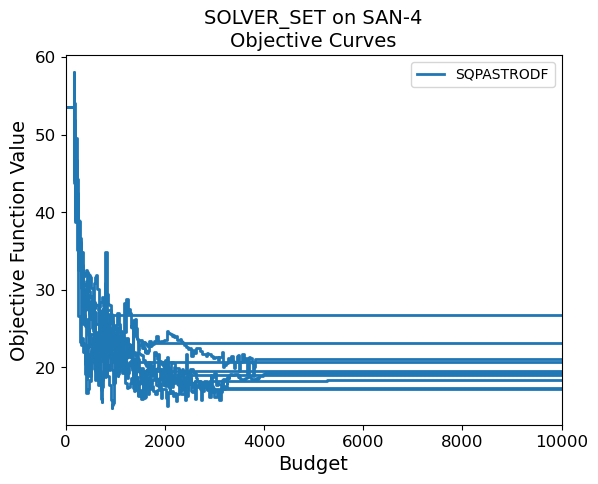

In [10]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_progress_curves(
        experiments=mymetaexperiment.experiments[0] , all_in_one = True, plot_type=PlotType.ALL, normalize=False,  save_as_pickle = True,
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_terminal_violin_unnorm.png')]
Plotting complete!


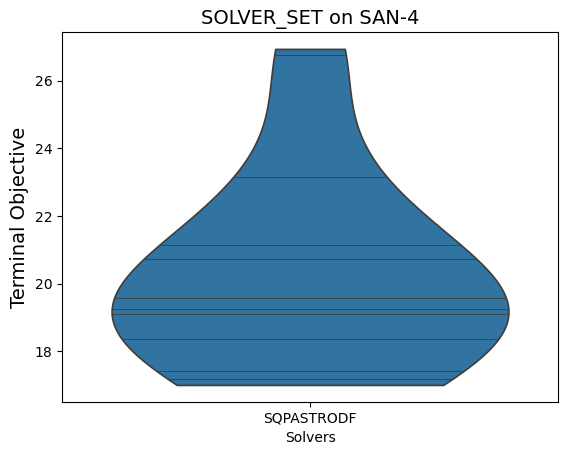

In [11]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_terminal_progress(
        experiments=mymetaexperiment.experiments[0], normalize = False
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_det_feasibility_progress_unnorm.png')]
Plotting complete!


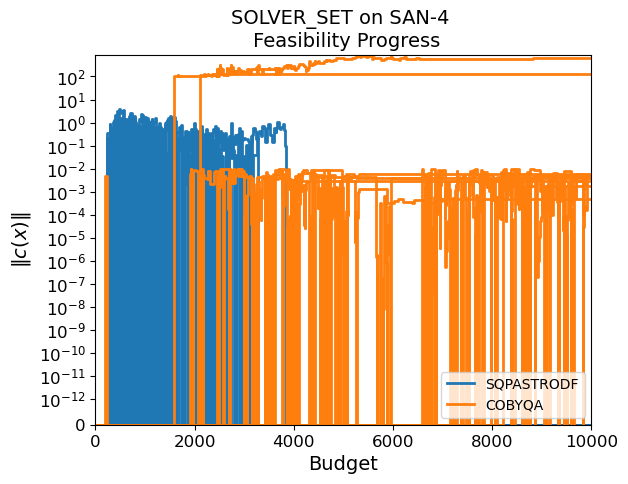

In [12]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments,  sym_log = True, score_type = "norm"
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_det_feasibility_progress_unnorm (1).png')]
Plotting complete!


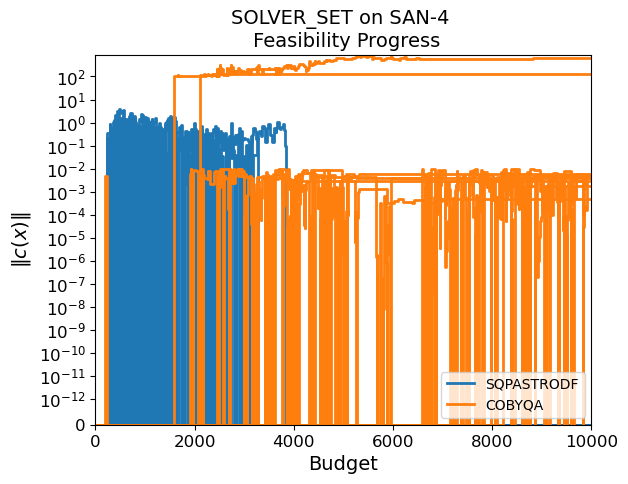

In [13]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, sym_log=True, log_base = 10, score_type = "norm"
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_det_feasibility_progress_unnorm (1) (2) (3) (4) (5) (6) (7) (8).png')]
Plotting complete!


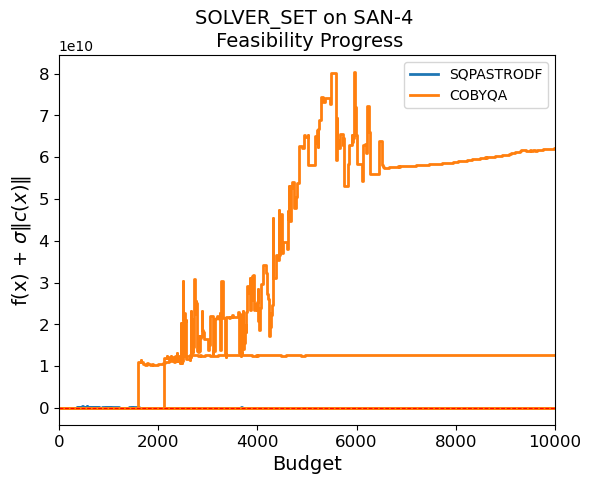

In [25]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, 
        log_scale = False, 
        score_type = "objective", 
        obj_const = 1e8, 
        feas_tol = 1e-2,
        save_as_pickle = True,
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_det_feasibility_progress_unnorm (1) (2) (3).png')]
Plotting complete!


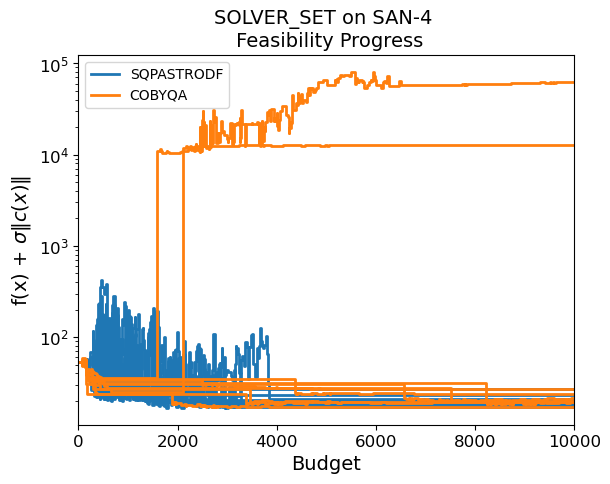

In [15]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, log_scale = False, score_type = "objective", feas_tol = 1e-2
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_det_feasibility_progress_unnorm (1) (2) (3) (4).png')]
Plotting complete!


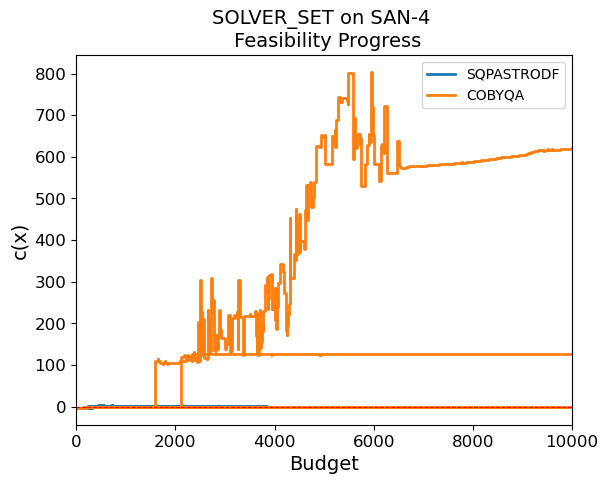

In [16]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, log_scale = False, score_type = "value", feas_tol = 1e-2,  save_as_pickle = True,
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_det_feasibility_scatter_unnorm.png')]
Plotting complete!


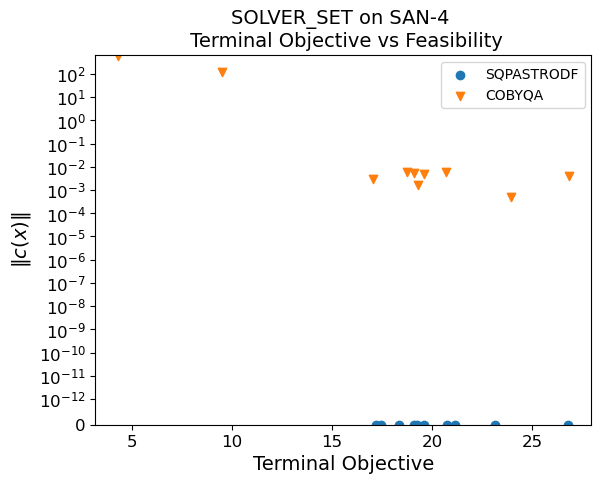

In [17]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, plot_conf_ints = False, score_type = "norm", sym_log= True,
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_det_feasibility_scatter_unnorm (1) (2) (3) (4).png')]
Plotting complete!


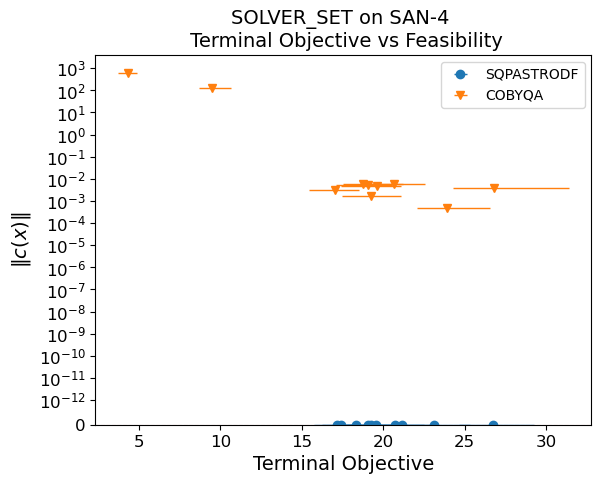

In [21]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, plot_conf_ints = True, sym_log = True, score_type = "norm", feas_tol = 1e-2, log_scale=True
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-07-19_13-00-45/plots/SOLVER_SET_SAN-4_det_feasibility_scatter_unnorm (1) (2).png')]
Plotting complete!


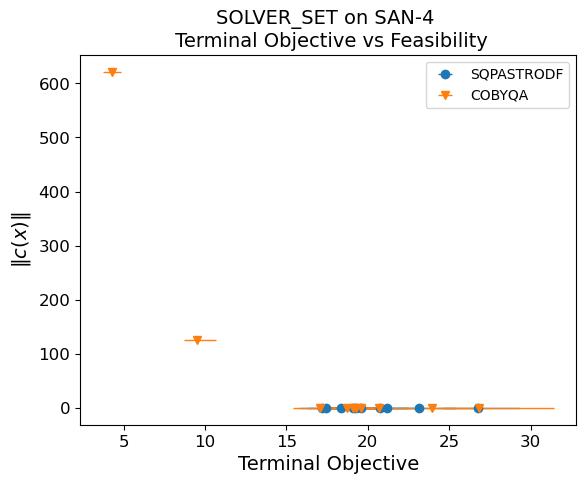

In [19]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, score_type = "norm", save_as_pickle = True, plot_conf_ints = True, feas_tol = 1e-4,  plot_zero = False, log_scale = False
    )
)

print("Plotting complete!")